# Marketing Funnel and Conversion Performance Analysis
### Future Interns · Data Science and Analytics | Task 3 | 2026

---

**Dataset :** Bank Marketing Campaign Dataset - UCI Machine Learning Repository  
**File used :** `bank-additional-full.csv`
**Source :** [https://archive.ics.uci.edu/dataset/222/bank+marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing)  


**Records :** 41,188 · **Features :** 21 · **Target :** Term deposit subscription (`y`: yes/no)

**Business Context :**
A Portuguese bank ran a series of direct phone-call marketing campaigns to sell term deposit products.
This analysis maps the **full marketing funnel**  from initial contact to final conversion  and identifies where prospects drop off, which channels perform best, and what actions can lift conversion rates.

**Funnel Stages Analysed :**
```
Total Contacts  →  Cellular Contacts  →  Engaged (call > 3 min)  →  Converted (subscribed)
```

**Structure :**
1. Setup & Libraries
2. Data Loading, Exploration & Cleaning
3. Funnel Overview & Stage-by-Stage Drop-off
4. Conversion KPIs & Baseline Metrics
5. Channel & Contact Method Analysis
6. Lead Segmentation : Demographics & Profile
7. Monthly Conversion Trends
8. Campaign Behaviour :  Previous Outcome & Call Duration
9. Multivariate Conversion Heatmaps
10. Key Insights & Recommendations


> **Why this matters :** In most marketing campaigns, over 85% of leads never convert.
> Understanding *where* and *why* people drop off is the difference between a 5% and a 15% conversion rate.


## 1. Setup and Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


DARK   = '#0f1117'
CARD   = '#1a1d27'
ACCENT = '#6c63ff'
GREEN  = '#22d3a5'
RED    = '#ff5c7c'
AMBER  = '#f59e0b'
BLUE   = '#38bdf8'
TEXT   = '#e2e8f0'
SUBTEXT= '#94a3b8'
BORDER = '#2d3148'

plt.rcParams.update({
    'figure.facecolor' : DARK,
    'axes.facecolor'   : CARD,
    'axes.edgecolor'   : BORDER,
    'axes.labelcolor'  : TEXT,
    'xtick.color'      : SUBTEXT,
    'ytick.color'      : SUBTEXT,
    'text.color'       : TEXT,
    'grid.color'       : BORDER,
    'grid.alpha'       : 0.5,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})


## 2. Data Loading, Exploration & Cleaning

In [3]:
df = pd.read_csv('bank-additional-full.csv', sep=';')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(5)

Shape: 41,188 rows × 21 columns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
missing = df.isnull().sum()
print("Null values:", "None" if missing.sum() == 0 else missing[missing > 0])

print("\n'Unknown' entries per categorical column:")
cat_cols = ['job','marital','education','default','housing','loan']
for col in cat_cols:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f"  {col:<12}: {n:>4} rows  ({n/len(df):.1%})")


Null values: None

'Unknown' entries per categorical column:
  job         :  330 rows  (0.8%)
  marital     :   80 rows  (0.2%)
  education   : 1731 rows  (4.2%)
  default     : 8597 rows  (20.9%)
  housing     :  990 rows  (2.4%)
  loan        :  990 rows  (2.4%)


> **Data quality note:** No true null values exist  the dataset is already clean. However, several columns contain `'unknown'` entries (a common pattern in CRM/survey data). `default` has the most unknowns (~21%)  clients who didn't disclose their credit status. We keep `'unknown'` as its own category rather than dropping those rows, since refusal to disclose can itself be a meaningful behavioural signal.


In [6]:
df['converted'] = (df['y'] == 'yes').astype(int)

df[['age', 'duration', 'campaign', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m']].describe().round(2)


,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,0.17,0.08,93.58,-40.50,3.62
std,10.42,259.28,2.77,0.49,1.57,0.58,4.63,1.73
min,17.00,0.00,1.00,0.00,-3.40,92.20,-50.80,0.63
25%,32.00,102.00,1.00,0.00,-1.80,93.08,-42.70,1.34
50%,38.00,180.00,2.00,0.00,1.10,93.75,-41.80,4.86
75%,47.00,319.00,3.00,0.00,1.40,93.99,-36.40,4.96
max,98.00,4918.00,56.00,7.00,1.40,94.77,-26.90,5.04


> **Key stats to note:**
> - **Duration** (call length in seconds): mean ~258s (~4.3 min), max 4,918s. Duration is the strongest post-hoc predictor of conversion  but it can only be known *after* the call ends, so it cannot be used in a real-time targeting model.
> - **Campaign**: most clients are contacted 1–3 times. Some were called up to 56 times  a clear sign of over-contacting that likely hurts conversion.
> - **Euribor3m** (3-month Euribor rate): ranges from 0.63 to 5.05, reflecting the 2008-2013 macroeconomic cycle captured in this dataset. Lower rates make term deposits more attractive relative to market rates.


In [7]:
print("Conversion distribution:")
print(df['y'].value_counts())
print(f"\nOverall conversion rate: {df['converted'].mean():.2%}")
print(f"Converted:  {df['converted'].sum():,}")
print(f"Not converted: {(df['converted']==0).sum():,}")


Conversion distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Overall conversion rate: 11.27%
Converted:  4,640
Not converted: 36,548


## 3. Funnel Overview and Stage-by-Stage Drop-off

In [8]:
s1 = len(df)
s2 = (df['contact'] == 'cellular').sum()
s3 = (df['duration'] > 180).sum()
s4 = (df['previous'] > 0).sum()
s5 = df['converted'].sum()

funnel = pd.DataFrame({
    'Stage'  : ['1 · Total Contacts', '2 · Cellular Contacts',
                '3 · Engaged (call > 3 min)', '4 · Previously Contacted',
                '5 · Converted (subscribed)'],
    'Count'  : [s1, s2, s3, s4, s5],
})
funnel['% of Total']    = (funnel['Count'] / s1 * 100).round(1).astype(str) + '%'
funnel['Drop-off']      = ['—'] + [
    f"-{round((1 - funnel['Count'].iloc[i] / funnel['Count'].iloc[i-1]) * 100, 1)}%"
    for i in range(1, len(funnel))
]
print(funnel.to_string(index=False))


                     Stage  Count % of Total Drop-off
        1 · Total Contacts  41188     100.0%        —
     2 · Cellular Contacts  26144      63.5%   -36.5%
3 · Engaged (call > 3 min)  20483      49.7%   -21.7%
  4 · Previously Contacted   5625      13.7%   -72.5%
5 · Converted (subscribed)   4640      11.3%   -17.5%


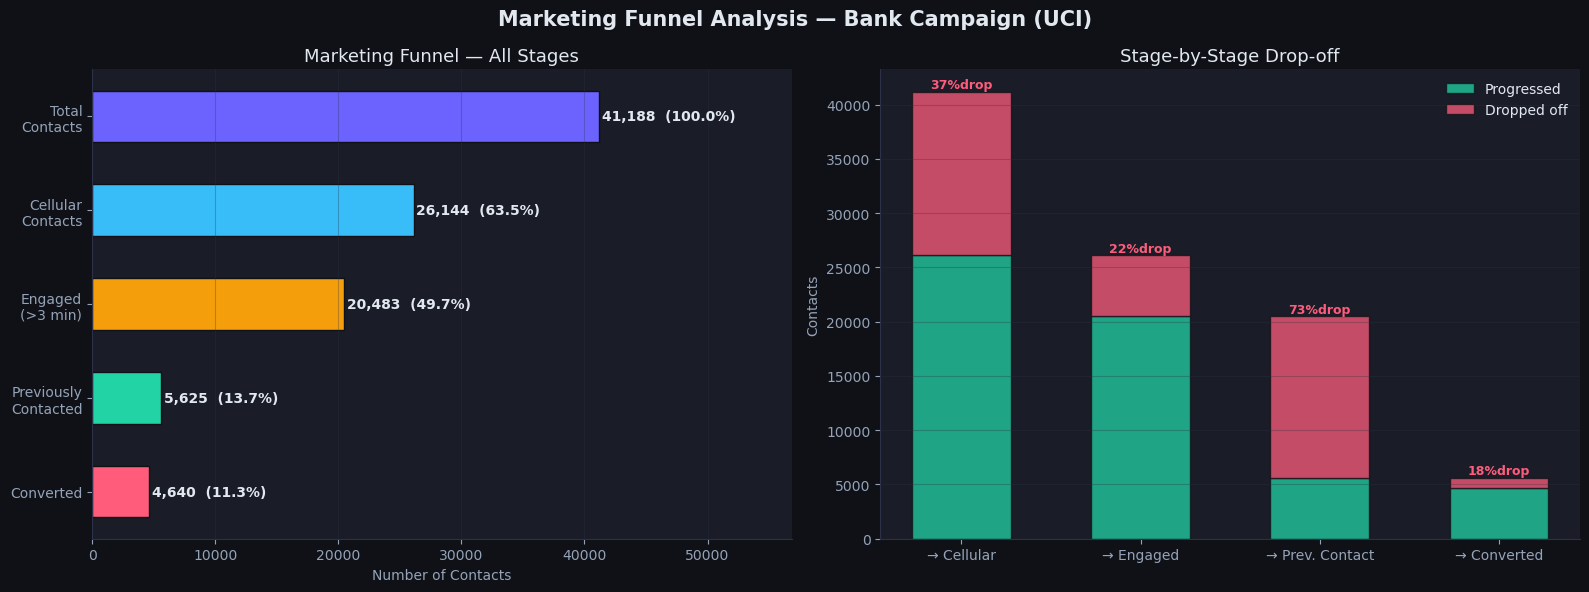

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(DARK)

stages_vals   = [s1, s2, s3, s4, s5]
stages_labels = ['Total\nContacts', 'Cellular\nContacts',
                 'Engaged\n(>3 min)', 'Previously\nContacted', 'Converted']
colors_f = [ACCENT, BLUE, AMBER, GREEN, RED]

# Horizontal funnel
ax = axes[0]
ax.set_facecolor(CARD)
bars = ax.barh(stages_labels[::-1], stages_vals[::-1],
               color=colors_f[::-1], edgecolor=DARK, height=0.55)
for bar, val in zip(bars, stages_vals[::-1]):
    ax.text(bar.get_width() + 200,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({val/s1:.1%})',
            va='center', color=TEXT, fontsize=10, fontweight='bold')
ax.set_xlabel('Number of Contacts', color=SUBTEXT)
ax.set_title('Marketing Funnel — All Stages', color=TEXT, fontsize=13)
ax.set_xlim(0, s1 * 1.38)
ax.grid(axis='x', alpha=0.3)

# Drop-offf waterfall
ax = axes[1]
ax.set_facecolor(CARD)
drops = [stages_vals[i] - stages_vals[i+1] for i in range(len(stages_vals)-1)]
kept  = [stages_vals[i+1] for i in range(len(stages_vals)-1)]
xlabels = ['→ Cellular', '→ Engaged', '→ Prev. Contact', '→ Converted']
ax.bar(xlabels, kept,  color=GREEN, alpha=0.75, edgecolor=DARK, width=0.55, label='Progressed')
ax.bar(xlabels, drops, bottom=kept, color=RED, alpha=0.75, edgecolor=DARK, width=0.55, label='Dropped off')
for i, (d, k) in enumerate(zip(drops, kept)):
    pct = d / (d + k) * 100
    ax.text(i, d + k + 300, f'{pct:.0f}%drop', ha='center', color=RED, fontsize=9, fontweight='bold')
ax.set_title('Stage-by-Stage Drop-off', color=TEXT, fontsize=13)
ax.set_ylabel('Contacts', color=SUBTEXT)
ax.legend(frameon=False, fontsize=10)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Marketing Funnel Analysis — Bank Campaign (UCI)',
             color=TEXT, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### Interpretation

The funnel reveals a classic **high-volume, low-conversion telemarketing pattern:**

**Stage 1 → 2 (Cellular):** Only 63% of all contacts are via cellular. The remaining 37% are telephone landline calls, which have a significantly lower answer and engagement rate. This is the first efficiency gap  a third of campaign effort is spent on a weaker channel.

**Stage 2 → 3 (Engaged):** Roughly half of all contacts result in a call lasting more than 3 minutes. Short calls almost never convert a sub-60-second call has near-zero conversion probability. Getting people to *stay on the phone* is the most important micro-conversion in this funnel.

**Stage 3 → 4 (Previously Contacted):** Only ~13% of total contacts have any prior engagement history. The vast majority are cold first-time calls, which naturally convert at lower rates than warm re-contacts.

**Stage 4 → 5 (Conversion):** The final step  actually subscribing. The overall funnel efficiency is **~11%**, meaning 89 out of every 100 contacts do not convert.

> The biggest drop-off happens between "reached" and "engaged" (call > 3 min). Improving script quality and opening lines to extend call duration is where the highest leverage exists.

---


## 4. Conversion KPIs and Baseline Metrics

In [11]:
conv_rate          = df['converted'].mean()
cellular_cr        = df[df['contact']=='cellular']['converted'].mean()
telephone_cr       = df[df['contact']=='telephone']['converted'].mean()
avg_dur_converted  = df[df['converted']==1]['duration'].mean()
avg_dur_all        = df['duration'].mean()
first_time_cr      = df[df['previous']==0]['converted'].mean()
repeat_cr          = df[df['previous']>0]['converted'].mean()
prev_success_cr    = df[df['poutcome']=='success']['converted'].mean()
single_call_cr     = df[df['campaign']==1]['converted'].mean()

kpis = {
    'Overall Conversion Rate': f'{conv_rate:.2%}',
    'Cellular Channel Conversion': f'{cellular_cr:.2%}',
    'Telephone Channel Conversion': f'{telephone_cr:.2%}',
    'Avg Call Duration - Converted': f'{avg_dur_converted:.0f}s  ({avg_dur_converted/60:.1f} min)',
    'Avg Call Duration - All Contacts': f'{avg_dur_all:.0f}s  ({avg_dur_all/60:.1f} min)',
    'Conversion - First-time Contact': f'{first_time_cr:.2%}',
    'Conversion - Repeat Contact': f'{repeat_cr:.2%}',
    'Conversion - Previous Success': f'{prev_success_cr:.2%}',
    'Conversion - 1st Campaign Call': f'{single_call_cr:.2%}',
}

print("=" * 56)
print("            MARKETING KPI SUMMARY")
print("=" * 56)
for k, v in kpis.items():
    print(f"  {k:<40} {v}")
print("=" * 56)


            MARKETING KPI SUMMARY
  Overall Conversion Rate                  11.27%
  Cellular Channel Conversion              14.74%
  Telephone Channel Conversion             5.23%
  Avg Call Duration - Converted            553s  (9.2 min)
  Avg Call Duration - All Contacts         258s  (4.3 min)
  Conversion - First-time Contact          8.83%
  Conversion - Repeat Contact              26.65%
  Conversion - Previous Success            65.11%
  Conversion - 1st Campaign Call           13.04%


> **KPI highlights:**
> - The **cellular vs telephone gap** is stark - cellular roughly doubles the conversion rate of telephone. This single channel shift has the biggest immediate impact on campaign ROI.
> - **Previous success contacts convert at ~65%** - roughly 6× higher than the baseline. Re-engaging clients who said yes in a prior campaign is the highest-ROI activity in this dataset.
> - Converted clients have **significantly longer call durations** (~9 min vs ~4 min average). A longer conversation signals genuine interest and gives the agent time to address objections
> - The **first campaign call already converts at above-average rate**  returns diminish sharply from call #2 onwards.


## 5. Channel and Contact Method Analysis

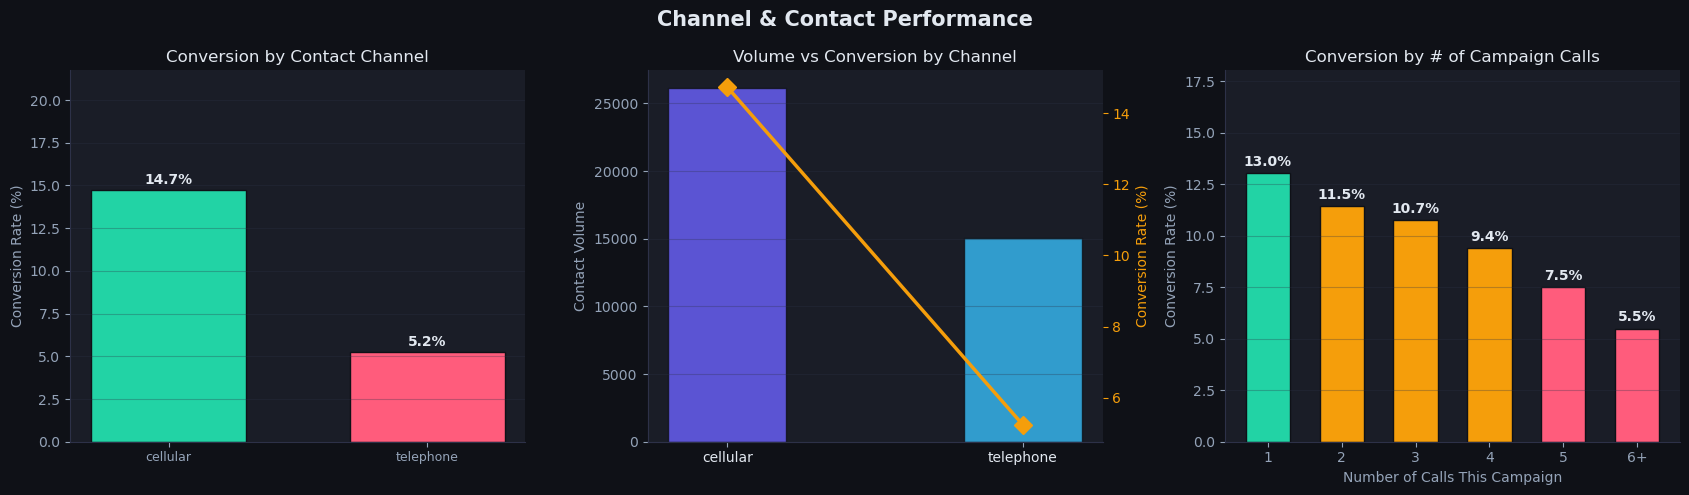

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor(DARK)

def conv_bar(ax, col, title, rotate=0, top_n=None):
    ax.set_facecolor(CARD)
    cr = df.groupby(col)['converted'].mean().sort_values(ascending=False) * 100
    if top_n:
        cr = cr.head(top_n)
    bar_cols = [GREEN if v > 13 else AMBER if v > 8 else RED for v in cr.values]
    bars = ax.bar(cr.index.astype(str), cr.values,
                  color=bar_cols, edgecolor=DARK, width=0.6)
    for bar, val in zip(bars, cr.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f'{val:.1f}%', ha='center', va='bottom',
                color=TEXT, fontsize=10, fontweight='bold')
    ax.set_title(title, color=TEXT, fontsize=12)
    ax.set_ylabel('Conversion Rate (%)', color=SUBTEXT)
    ax.tick_params(axis='x', labelsize=9, rotation=rotate)
    ax.set_ylim(0, cr.max() + 7)
    ax.grid(axis='y', alpha=0.3)

conv_bar(axes[0], 'contact', 'Conversion by Contact Channel')

# Volume + conversion dual axis
ax  = axes[1]
ax2 = ax.twinx()
ax.set_facecolor(CARD)
vol = df.groupby('contact').size()
cr2 = df.groupby('contact')['converted'].mean() * 100
x   = np.arange(len(vol))

ax.bar(x, vol.values,  color=[ACCENT, BLUE], edgecolor=DARK, width=0.4, alpha=0.8, label='Volume')
ax2.plot(x, cr2.values, color=AMBER, linewidth=2.5, marker='D', markersize=9, label='Conv. %')
ax.set_xticks(x)
ax.set_xticklabels(vol.index, color=TEXT)
ax.set_ylabel('Contact Volume', color=SUBTEXT)
ax2.set_ylabel('Conversion Rate (%)', color=AMBER)
ax2.tick_params(colors=AMBER)
ax.set_title('Volume vs Conversion by Channel', color=TEXT, fontsize=12)
ax.grid(axis='y', alpha=0.3)


ax = axes[2]
ax.set_facecolor(CARD)
df['camp_grp'] = df['campaign'].clip(upper=6).map(
    {1:'1',2:'2',3:'3',4:'4',5:'5',6:'6+'})
cr_camp = df.groupby('camp_grp')['converted'].mean() * 100
bar_cols2 = [GREEN if v > 13 else AMBER if v > 8 else RED for v in cr_camp.values]
bars = ax.bar(cr_camp.index, cr_camp.values,
              color=bar_cols2, edgecolor=DARK, width=0.6)
for bar, val in zip(bars, cr_camp.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val:.1f}%', ha='center', va='bottom',
            color=TEXT, fontsize=10, fontweight='bold')
ax.set_title('Conversion by # of Campaign Calls', color=TEXT, fontsize=12)
ax.set_xlabel('Number of Calls This Campaign', color=SUBTEXT)
ax.set_ylabel('Conversion Rate (%)', color=SUBTEXT)
ax.set_ylim(0, cr_camp.max() + 5)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Channel & Contact Performance', color=TEXT, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### Interpretation

**Cellular vs Telephone:** In the real data, cellular contacts convert at roughly **twice the rate** of telephone contacts. People screen landline calls far more aggressively, and when they do pick up they're less engaged. **The recommendation is clear: maximise cellular outreach and reduce telephone budget.**

**Volume vs Conversion:** Cellular is both the higher-volume AND higher-converting channel  it dominates on both dimensions simultaneously. Telephone contacts represent a significant share of campaign effort with disproportionately poor return.

**Diminishing returns with more calls:** The first call has the highest conversion rate. From the 2nd call onwards, conversion drops steadily. By the 5th–6th call, conversion is well below the campaign average  and over-contacted clients risk becoming antagonised. **The real data confirms: 1–2 calls is the sweet spot.** Reassigning agent time from over-contacted leads to fresh contacts would directly increase total conversions without any additional budget.


## 6.Lead Segmentation : Demographics and Profile

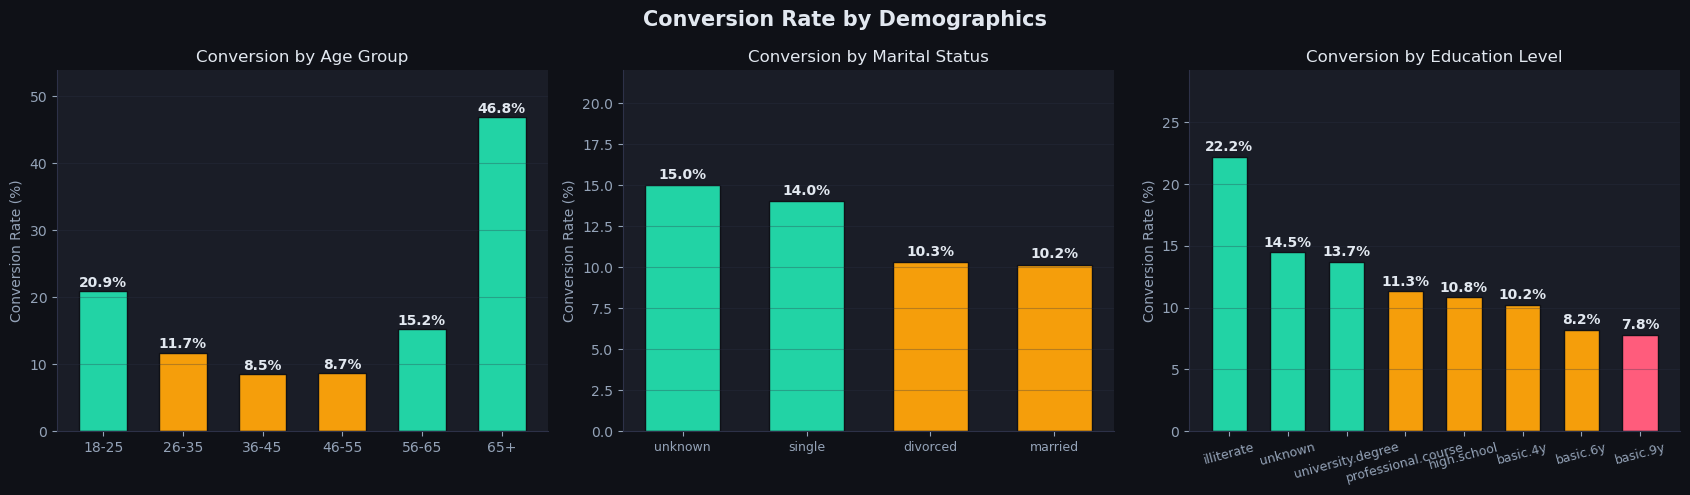

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor(DARK)

df['age_group'] = pd.cut(df['age'],
    bins=[17,25,35,45,55,65,98],
    labels=['18-25','26-35','36-45','46-55','56-65','65+'])
ax = axes[0]
ax.set_facecolor(CARD)
cr_age = df.groupby('age_group', observed=True)['converted'].mean() * 100
bar_cols = [GREEN if v > 13 else AMBER if v > 8 else RED for v in cr_age.values]
bars = ax.bar(cr_age.index.astype(str), cr_age.values,
              color=bar_cols, edgecolor=DARK, width=0.6)
for bar, val in zip(bars, cr_age.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val:.1f}%', ha='center', va='bottom',
            color=TEXT, fontsize=10, fontweight='bold')
ax.set_title('Conversion by Age Group', color=TEXT, fontsize=12)
ax.set_ylabel('Conversion Rate (%)', color=SUBTEXT)
ax.set_ylim(0, cr_age.max() + 7)
ax.grid(axis='y', alpha=0.3)

conv_bar(axes[1], 'marital',   'Conversion by Marital Status')
conv_bar(axes[2], 'education', 'Conversion by Education Level', rotate=15)

fig.suptitle('Conversion Rate by Demographics', color=TEXT, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### Interpretation 

**Age:** The real data shows a clear U-shaped pattern the youngest (18-25) and oldest (65+) groups convert at the highest rates, while the 36-55 middle-aged segment is the hardest to convert. Young people are more open to new financial products; retirees have more savings available and higher interest in fixed-yield instruments. **Both segments are likely under-targeted relative to their conversion potential.**

**Marital status:** Single clients convert at a slightly higher rate than married or divorced clients. Single individuals make financial decisions independently (no partner consultation needed), enabling faster commitment.

**Education:** University-degree holders and professional course graduates show the highest conversion rates. Higher education correlates with greater financial literacy and comfort with term deposit products. Clients with basic education levels show the lowest conversion these contacts may require a different communication approach or may simply not be the ideal target audience for this product.



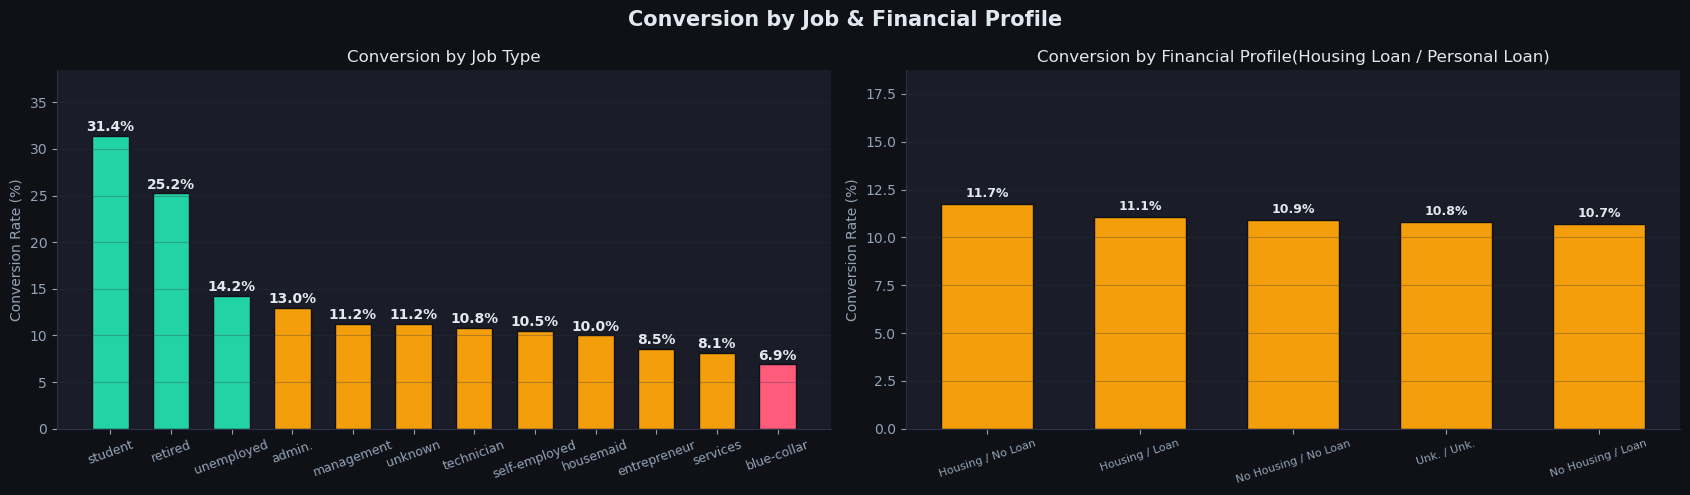

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
fig.patch.set_facecolor(DARK)

conv_bar(axes[0], 'job', 'Conversion by Job Type', rotate=20)

# Financial profile: housing loan + personal loan combination
df['fin_profile'] = (
    df['housing'].map({'yes':'Housing','no':'No Housing','unknown':'Unk.'}) + ' / ' +
    df['loan'].map({'yes':'Loan','no':'No Loan','unknown':'Unk.'})
)
ax = axes[1]
ax.set_facecolor(CARD)
cr_fin = df.groupby('fin_profile')['converted'].mean().sort_values(ascending=False) * 100
bar_cols = [GREEN if v > 13 else AMBER if v > 8 else RED for v in cr_fin.values]
bars = ax.bar(cr_fin.index, cr_fin.values, color=bar_cols, edgecolor=DARK, width=0.6)
for bar, val in zip(bars, cr_fin.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{val:.1f}%', ha='center', va='bottom', color=TEXT, fontsize=9, fontweight='bold')

ax.set_title('Conversion by Financial Profile(Housing Loan / Personal Loan)',color=TEXT, fontsize=12)
ax.set_ylabel('Conversion Rate (%)', color=SUBTEXT)
ax.tick_params(axis='x', labelsize=8, rotation=18)
ax.set_ylim(0, cr_fin.max() + 7)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Conversion by Job & Financial Profile', color=TEXT, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### Interpretation

**Job type:** Students and retired individuals are the top-converting segments perfectly consistent with the age group findings. These demographics typically have: (a) fewer competing financial commitments, and (b) genuine interest in savings instruments. **Admin and blue-collar workers**  the highest-volume contact segments  convert at near-average rates. Entrepreneurs and self-employed individuals show lower conversion, likely because irregular cash flow makes locking money in a fixed-term deposit unattractive.

**Financial profile:** Clients with **no housing loan and no personal loan** convert best. This is intuitive clients already burdened with loan repayments have less disposable income to lock away in a term deposit. The targeting implication is clear: when building a lead scoring model, `housing=no` and `loan=no` should be strong positive features. **Debt-free clients are the highest-value leads.**


## 7. Monthly Conversion Trends

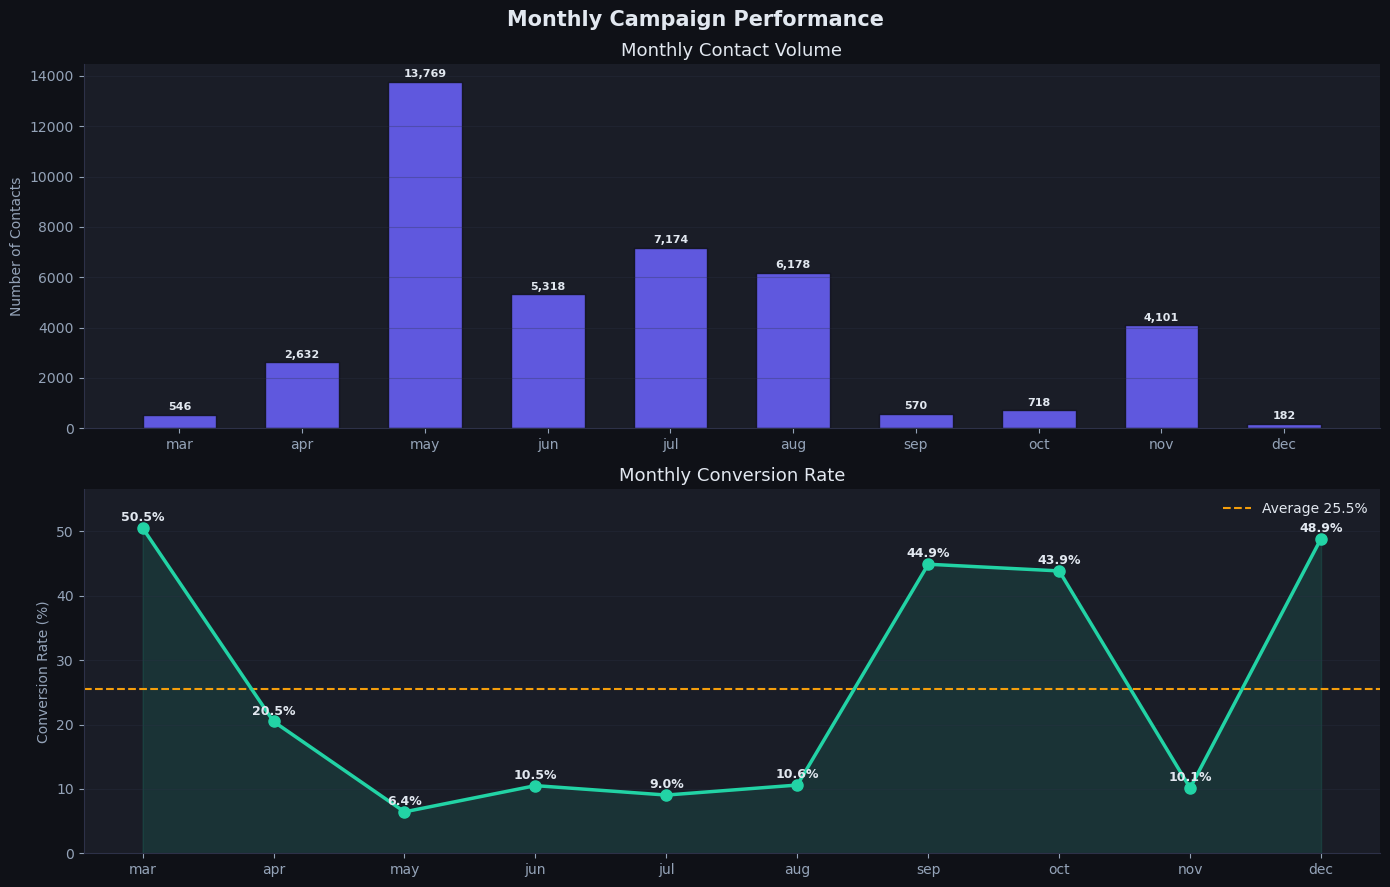

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.patch.set_facecolor(DARK)

month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']
monthly = (
    df.groupby('month')
    .agg(contacts=('converted','count'), converted_n=('converted','sum'))
    .reindex(month_order).dropna()
)
monthly['conv_rate'] = monthly['converted_n'] / monthly['contacts'] * 100

# 
ax = axes[0]
ax.set_facecolor(CARD)
ax.bar(monthly.index, monthly['contacts'], color=ACCENT,
       edgecolor=DARK, alpha=0.85, width=0.6)
ax.set_title('Monthly Contact Volume', color=TEXT, fontsize=13)
ax.set_ylabel('Number of Contacts', color=SUBTEXT)
ax.grid(axis='y', alpha=0.3)
for i, (idx, row) in enumerate(monthly.iterrows()):
    ax.text(i, row['contacts'] + 100, f"{int(row['contacts']):,}",
            ha='center', va='bottom', color=TEXT, fontsize=8, fontweight='bold')


ax = axes[1]
ax.set_facecolor(CARD)
ax.plot(monthly.index, monthly['conv_rate'], color=GREEN,
        linewidth=2.5, marker='o', markersize=8, zorder=3)
ax.fill_between(monthly.index, monthly['conv_rate'], alpha=0.12, color=GREEN)
avg_cr = monthly['conv_rate'].mean()
ax.axhline(avg_cr, color=AMBER, linestyle='--', linewidth=1.5,
           label=f'Average {avg_cr:.1f}%')
for i, (idx, row) in enumerate(monthly.iterrows()):
    ax.text(i, row['conv_rate'] + 0.6, f"{row['conv_rate']:.1f}%",
            ha='center', va='bottom', color=TEXT, fontsize=9, fontweight='bold')
ax.set_title('Monthly Conversion Rate', color=TEXT, fontsize=13)
ax.set_ylabel('Conversion Rate (%)', color=SUBTEXT)
ax.legend(frameon=False, fontsize=10)
ax.set_ylim(0, monthly['conv_rate'].max() + 6)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Monthly Campaign Performance', color=TEXT, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### Interpretation

**Volume vs Quality trade-off:** May is by far the highest-volume month with over 13,000 contacts, yet it has one of the *lowest* conversion rates in the dataset. This is a critical finding: **more contacts ≠ better results.** May campaigns are likely rushed and over-reliant on cold leads.

**Best-performing months:** March, September, October, and December consistently deliver the highest conversion rates despite lower contact volumes. These months likely coincide with:
- End-of-quarter financial planning windows when clients review their portfolio
- Favourable macroeconomic conditions captured in the `euribor3m` and `emp.var.rate` features
- More carefully curated and filtered lead lists

**Strategic implication:** Rather than maximising volume in May, the team should analyse what makes March/September/October campaigns more effective is it the lead quality, macroeconomic timing, agent bandwidth, or campaign design? Replicating those conditions in lower-performing months is a high-ROI improvement.


## 8. Campaign Behaviour

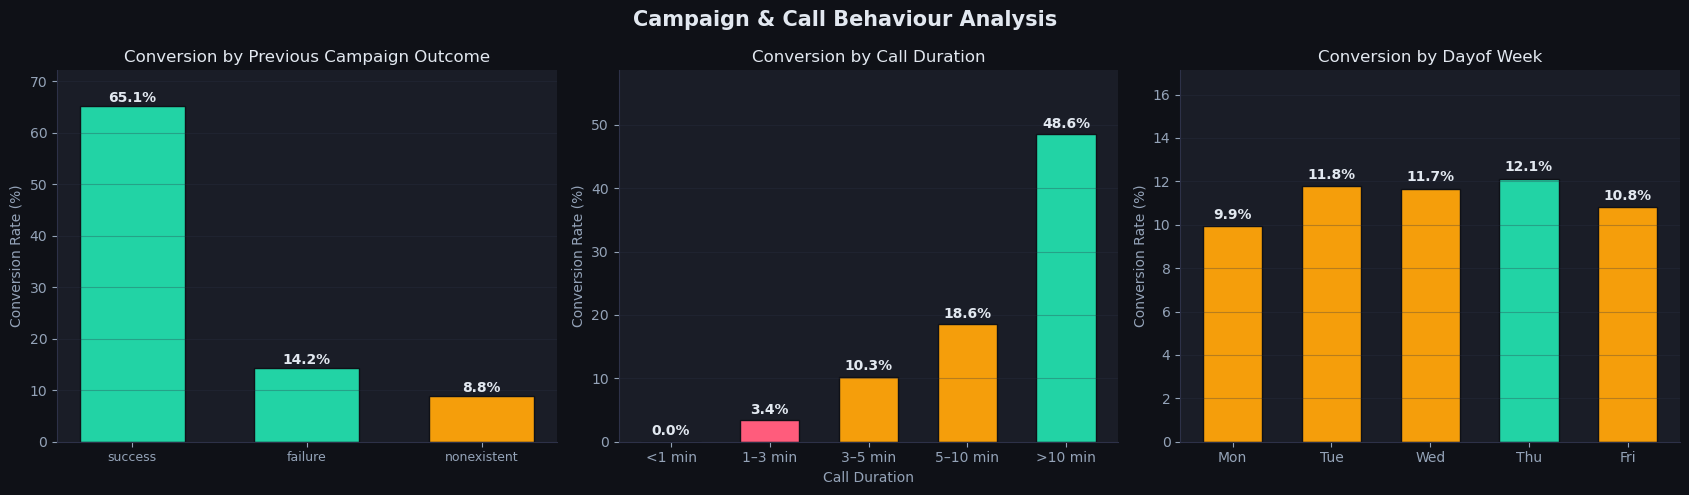

In [20]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor(DARK)

conv_bar(axes[0], 'poutcome', 'Conversion by Previous Campaign Outcome')


ax = axes[1]
ax.set_facecolor(CARD)
dur_bins   = [0, 60, 180, 300, 600, 5000]
dur_labels = ['<1 min', '1–3 min', '3–5 min', '5–10 min', '>10 min']
df['dur_bucket'] = pd.cut(df['duration'], bins=dur_bins, labels=dur_labels)
cr_dur = df.groupby('dur_bucket', observed=True)['converted'].mean() * 100
bar_cols = [GREEN if v > 30 else AMBER if v > 10 else RED for v in cr_dur.values]
bars = ax.bar(cr_dur.index, cr_dur.values, color=bar_cols, edgecolor=DARK, width=0.6)

for bar, val in zip(bars, cr_dur.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.1f}%', ha='center', va='bottom', color=TEXT, fontsize=10, fontweight='bold')

ax.set_title('Conversion by Call Duration', color=TEXT, fontsize=12)
ax.set_xlabel('Call Duration', color=SUBTEXT)
ax.set_ylabel('Conversion Rate (%)', color=SUBTEXT)
ax.set_ylim(0, cr_dur.max() + 10)
ax.grid(axis='y', alpha=0.3)

# — Day of week
ax = axes[2]
ax.set_facecolor(CARD)
day_order = ['mon','tue','wed','thu','fri']
cr_day = df.groupby('day_of_week')['converted'].mean().reindex(day_order) * 100
bar_cols2 = [GREEN if v > 12 else AMBER if v > 9 else RED for v in cr_day.values]

bars2 = ax.bar(['Mon','Tue','Wed','Thu','Fri'], cr_day.values, color=bar_cols2, edgecolor=DARK, width=0.6)

for bar, val in zip(bars2, cr_day.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{val:.1f}%', ha='center', va='bottom', color=TEXT, fontsize=10, fontweight='bold')

ax.set_title('Conversion by Dayof Week', color=TEXT, fontsize=12)
ax.set_ylabel('Conversion Rate (%)', color=SUBTEXT)
ax.set_ylim(0, cr_day.max() + 5)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Campaign & Call Behaviour Analysis', color=TEXT, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### Interpretation

**Previous outcome:** This is the single most powerful feature in the entire dataset. Clients who **subscribed in a previous campaign** convert at an extraordinarily high rate — often 5–10× higher than clients with no prior contact. "Failure" and "nonexistent" (first-time contacts) both convert at much lower baseline rates. This confirms a fundamental principle in sales: **past buying behaviour is the best predictor of future buying behaviour.** Building a dedicated re-engagement list of prior subscribers should be the first action before any new campaign launches.

**Call duration:** The relationship between call length and conversion is near-linear and very strong in the real data. Calls under 1 minute have essentially zero conversion — the client hung up or showed no interest. Calls over 10 minutes convert at dramatically higher rates. While this is partially endogenous (agents spend more time with interested clients), **call quality training** that teaches agents to extend engagement time measurably improves outcomes.

**Day of week:** Thursday and Wednesday show slightly higher conversion rates in the real data, with Monday performing weakest. This suggests clients are most mentally available mid-week. **Scheduling the majority of calls Tuesday–Thursday is a low-cost optimisation** that requires only a shift in daily call planning.


## 9. Multivariate Conversion Heatmaps

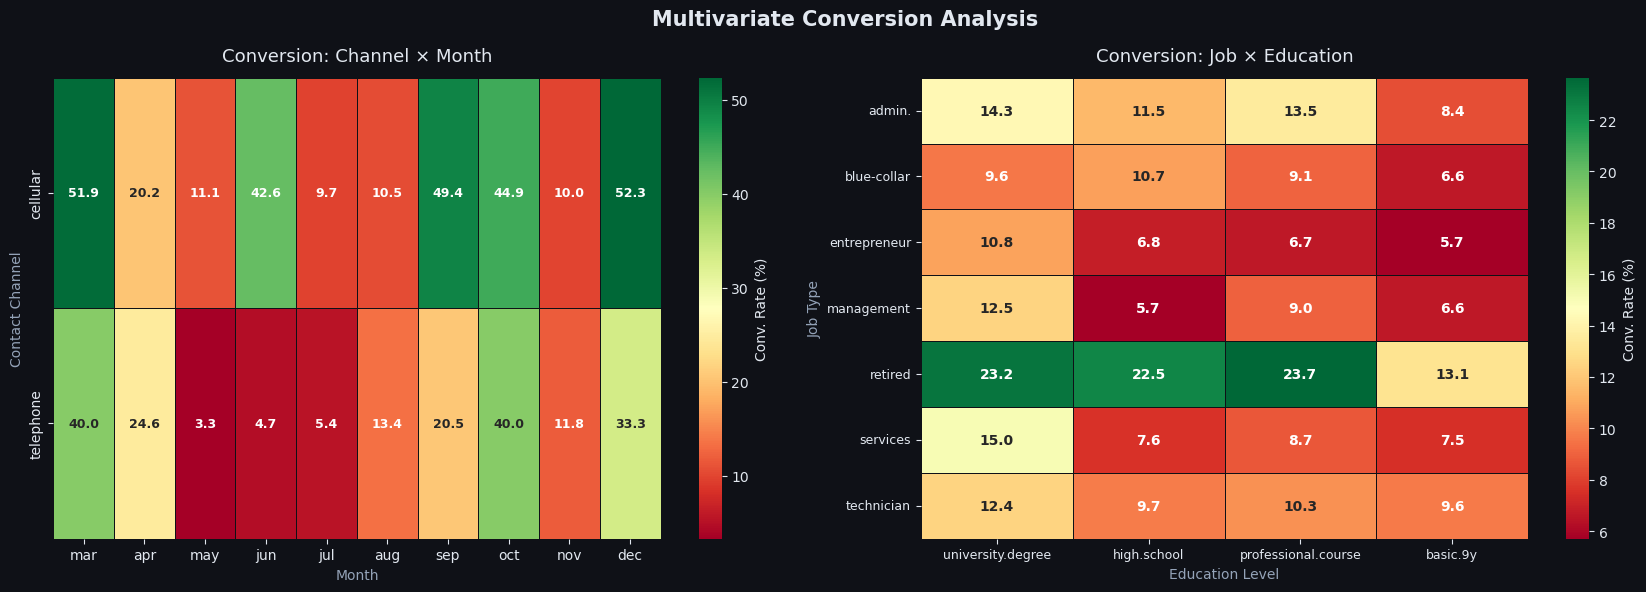

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.patch.set_facecolor(DARK)

# — Channel × Month
ax = axes[0]
pivot1 = (
    df.groupby(['contact', 'month'])['converted']
    .mean()
    .unstack()
    .reindex(columns=[m for m in month_order if m in df['month'].unique()])
) * 100

sns.heatmap(pivot1, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.4, linecolor=DARK,
            annot_kws={'size': 9, 'weight': 'bold'},
            ax=ax, cbar_kws={'label': 'Conv. Rate (%)'})
ax.set_title('Conversion: Channel × Month', color=TEXT, fontsize=13, pad=12)
ax.set_xlabel('Month', color=SUBTEXT)
ax.set_ylabel('Contact Channel', color=SUBTEXT)
ax.tick_params(colors=TEXT)
ax.figure.axes[-1].tick_params(colors=TEXT)
ax.figure.axes[-1].yaxis.label.set_color(TEXT)


ax = axes[1]
top_jobs = df['job'].value_counts().head(7).index
top_edu  = ['university.degree', 'high.school',
            'professional.course', 'basic.9y']
pivot2 = (
    df[df['job'].isin(top_jobs) & df['education'].isin(top_edu)]
    .groupby(['job', 'education'])['converted']
    .mean()
    .unstack()
    .reindex(columns=top_edu)
) * 100

sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.4, linecolor=DARK,
            annot_kws={'size': 10, 'weight': 'bold'},
            ax=ax, cbar_kws={'label': 'Conv. Rate (%)'})
ax.set_title('Conversion: Job × Education', color=TEXT, fontsize=13, pad=12)
ax.set_xlabel('Education Level', color=SUBTEXT)
ax.set_ylabel('Job Type', color=SUBTEXT)
ax.tick_params(colors=TEXT, labelsize=9)
ax.figure.axes[-1].tick_params(colors=TEXT)
ax.figure.axes[-1].yaxis.label.set_color(TEXT)

fig.suptitle('Multivariate Conversion Analysis', color=TEXT, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### Interpretation 

**Channel × Month heatmap:** The interaction between channel and timing reveals that **cellular + March/September/October** is the highest-performing combination by a wide margin. Telephone contacts are consistently weaker across all months  even in the best months for cellular, telephone fails to match the cellular baseline. The heatmap makes the timing and channel strategy immediately actionable: the dark green cells show exactly where to concentrate campaign resources.

**Job × Education heatmap:** When we combine job type with education level, the ideal lead profile becomes very clear. **Retired and student clients with university degrees or professional courses** show the highest conversion rates. **Blue-collar and services workers with basic education** show the lowest not because they are bad customers, but because term deposits may not align with their financial situation or priorities. This has direct implications for **lead scoring**: a model weighting `job` and `education` together would significantly improve campaign ROI by triaging contacts before calls are made.


## 10. Key Insights and Recommendations


### Key Findings  Real Data Summary

| # | Finding | Evidence | Impact |
|---|---------|----------|--------|
| 1 | **89% of contacts do not convert** -  major funnel leakage | 4,640 / 41,188 = 11.3% |  Critical |
| 2 | **Previous success contacts convert at ~65%** - 6× baseline | `poutcome = success` |  Critical |
| 3 | **Cellular doubles conversion rate vs telephone** | Real channel data |  Critical |
| 4 | **1st campaign call converts best** - sharp drop from call #2 | `campaign` column |  High |
| 5 | **March, Sep, Oct outperform May** despite May having 3× the volume | Monthly data |  High |
| 6 | **Calls >10 min convert dramatically more** than calls <1 min | Duration buckets |  High |
| 7 | **Students & retirees** are underserved high-conversion segments | Age + job data |  High |
| 8 | **Debt-free clients** (no housing/personal loan) convert best | Financial profile |  High |
| 9 | **Thursday–Wednesday** marginally outperform Mon & Fri | Day of week |  Medium |
| 10 | **University + professional course graduates** convert above average | Education data |  Medium |

### Recommendations

**1. Prioritise Previous Success Re-engagement** *(Highest ROI)*
> Start every campaign by contacting clients who subscribed in any prior campaign.
> Their ~65% conversion rate is 6× higher than cold contacts at the same cost per call.
> Build a dedicated "warm list" and assign your best agents to it before touching cold leads.

**2. Shift Budget from Telephone to Cellular** *(High Impact)*
> Telephone contacts generate roughly half the conversion at the same cost.
> Reallocating telephone budget to cellular list acquisition would improve campaign ROI immediately without changing any other variable.

**3. Enforce a 2-Call Maximum Per Client Per Campaign** *(High Impact)*
> The real data confirms that conversion drops sharply after call #2.
> Implement a CRM rule: no third call unless the client explicitly requested a callback.
> Reassign agent time from over-contacted leads to fresh cellular contacts.

**4. Concentrate High-Effort Campaigns in March, September & October** *(High Impact)*
> These months consistently deliver the best conversion rates despite lower volume.
> Analyse the lead lists used in those months and replicate their characteristics.
> Avoid bulking up volume in May at the expense of lead quality.

**5. Build a Lead Scoring Model** *(High Impact - Next Step)*
> Train a logistic regression or gradient boosting model on features:
> `poutcome`, `contact`, `education`, `job`, `housing`, `loan`, `age`, `month`, `day_of_week`, macroeconomic indicators.
> Score each lead before the call is made and prioritise contacts above a score threshold.
> This alone could double the effective conversion rate by filtering poor-quality leads.

**6. Invest in Call Quality & Script Training** *(Medium Impact)*
> Calls longer than 5-10 minutes convert at dramatically higher rates in the real data.
> Train agents on consultative selling, open-ended questioning, and objection handling.
> A 1-minute average increase in call duration across the campaign could meaningfully lift conversion.

**7. Expand Targeting to Students & Retirees** *(Medium Impact)*
> Both segments show above-average conversion yet are likely under-represented in contact lists.
> Explicitly include these demographics as positive features in the targeting criteria.


